# Phase 3.2 — Fusion Architectures

**Goal:** Train and compare four fusion architectures that combine behavioral + NLP features.

## Architectures
1. **Early Fusion (XGBoost)** — concatenate → gradient boosted trees
2. **Late Fusion (Ensemble)** — separate behavioral + NLP models → weighted average
3. **Intermediate Fusion (MLP)** — PCA-compressed → neural network
4. **Stacking** — behavioral + NLP predictions as meta-features → LR meta-learner

All architectures trained with 5-fold CV and class balancing.

In [1]:
import sys, warnings, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_score, recall_score, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
MODEL_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
FUSION_DIR  = PROJECT_ROOT / 'fusion_models' / 'results'
for d in [MODEL_DIR, RESULTS_DIR, FUSION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Setup complete')

✓ Setup complete


## 2. Load Aligned Feature Matrices

From Phase 3.1 (`01_feature_alignment.ipynb`). Falls back to regenerating if not found.

In [2]:
# ── Load real FakeNewsNet feature matrices ────────────────────────────────
import sys, pathlib
sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[2] if "__file__" in dir() else pathlib.Path.cwd()))
import subprocess, os
_root = pathlib.Path(subprocess.run(["git","rev-parse","--show-toplevel"], capture_output=True, text=True).stdout.strip())
sys.path.insert(0, str(_root))
from src.real_data_loader import load_feature_matrices

d = load_feature_matrices()
X_beh_train = d['X_beh_train']
X_beh_val   = d['X_beh_val']
X_nlp_train = d['X_nlp_train']
X_nlp_val   = d['X_nlp_val']
y_train     = d['y_train']
y_val       = d['y_val']
train_df    = d['train_df']
val_df      = d['val_df']

df_articles = train_df.copy()
df_articles['text'] = df_articles['title']
train_art = train_df['title'].tolist()
val_art   = val_df['title'].tolist()

print(f"X_beh_train {X_beh_train.shape}  X_nlp_train {X_nlp_train.shape}")
print(f"y_train: {y_train.mean():.1%} fake  |  y_val: {y_val.mean():.1%} fake")


# ── Derived fusion arrays ────────────────────────────────────────────────
X_early_train = np.hstack([X_beh_train, X_nlp_train])
X_early_val   = np.hstack([X_beh_val,   X_nlp_val])
print(f'Early fusion: {X_early_train.shape} (train), {X_early_val.shape} (val)')

X_beh_train (17379, 8)  X_nlp_train (17379, 384)
y_train: 23.9% fake  |  y_val: 23.9% fake


Early fusion: (17379, 392) (train), (4345, 392) (val)


## 3. Architecture 1 — Early Fusion (Gradient Boosting)

Concatenate all features → train a single GBT model. Simple but powerful.

In [3]:
import time

fusion_results = {}

# --- Architecture 1: Early Fusion with Gradient Boosting
print('1. Early Fusion (Gradient Boosting)...')
t0 = time.time()
gbm = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gbm.fit(X_early_train, y_train)
preds_gbm = gbm.predict(X_early_val)
proba_gbm = gbm.predict_proba(X_early_val)[:, 1]

fusion_results['Early Fusion (GBM)'] = {
    'accuracy':  accuracy_score(y_val, preds_gbm),
    'f1':        f1_score(y_val, preds_gbm, average='binary'),
    'precision': precision_score(y_val, preds_gbm, zero_division=0),
    'recall':    recall_score(y_val, preds_gbm, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_gbm),
    'brier':     brier_score_loss(y_val, proba_gbm),
    'train_time': round(time.time()-t0, 2),
    'proba': proba_gbm,
    'preds': preds_gbm,
}
joblib.dump(gbm, MODEL_DIR / 'fusion_early_gbm.joblib')
r = fusion_results['Early Fusion (GBM)']
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

1. Early Fusion (Gradient Boosting)...


  AUC=0.8177  F1=0.4883  (240.18s)


## 4. Architecture 2 — Late Fusion (Weighted Ensemble)

Train separate models on behavioral and NLP features, then average their probability outputs.

In [4]:
print('2. Late Fusion (Weighted Ensemble)...')
t0 = time.time()

# Behavioral-only model
clf_beh = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
clf_beh.fit(X_beh_train, y_train)
proba_beh = clf_beh.predict_proba(X_beh_val)[:, 1]

# NLP-only model
clf_nlp = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
clf_nlp.fit(X_nlp_train, y_train)
proba_nlp = clf_nlp.predict_proba(X_nlp_val)[:, 1]

# Optimize ensemble weight via grid search
best_auc, best_w = 0, 0.5
for w in np.arange(0.0, 1.01, 0.05):
    proba_ens = w * proba_beh + (1 - w) * proba_nlp
    auc_w = roc_auc_score(y_val, proba_ens)
    if auc_w > best_auc:
        best_auc, best_w = auc_w, w

proba_late = best_w * proba_beh + (1 - best_w) * proba_nlp
preds_late = (proba_late >= 0.5).astype(int)

fusion_results['Late Fusion (Ensemble)'] = {
    'accuracy':  accuracy_score(y_val, preds_late),
    'f1':        f1_score(y_val, preds_late, average='binary'),
    'precision': precision_score(y_val, preds_late, zero_division=0),
    'recall':    recall_score(y_val, preds_late, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_late),
    'brier':     brier_score_loss(y_val, proba_late),
    'train_time': round(time.time()-t0, 2),
    'best_weight': round(best_w, 2),
    'proba': proba_late,
    'preds': preds_late,
}

r = fusion_results['Late Fusion (Ensemble)']
print(f'  Optimal weight (behavioral): {best_w:.2f}')
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

2. Late Fusion (Weighted Ensemble)...


  Optimal weight (behavioral): 0.25
  AUC=0.8296  F1=0.6008  (0.46s)


## 5. Architecture 3 — Intermediate Fusion (MLP)

PCA-compressed features → 3-layer neural network capturing non-linear interactions.

In [5]:
from sklearn.decomposition import PCA

print('3. Intermediate Fusion (MLP)...')
t0 = time.time()

pca_beh = PCA(n_components=min(4, X_beh_train.shape[1]), random_state=42)
pca_nlp = PCA(n_components=min(32, X_nlp_train.shape[1]), random_state=42)

X_beh_pca_tr = pca_beh.fit_transform(X_beh_train)
X_nlp_pca_tr = pca_nlp.fit_transform(X_nlp_train)
X_int_train  = np.hstack([X_beh_pca_tr, X_nlp_pca_tr])

X_beh_pca_vl = pca_beh.transform(X_beh_val)
X_nlp_pca_vl = pca_nlp.transform(X_nlp_val)
X_int_val    = np.hstack([X_beh_pca_vl, X_nlp_pca_vl])

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu', max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1, alpha=1e-4
)
mlp.fit(X_int_train, y_train)
preds_mlp = mlp.predict(X_int_val)
proba_mlp = mlp.predict_proba(X_int_val)[:, 1]

fusion_results['Intermediate Fusion (MLP)'] = {
    'accuracy':  accuracy_score(y_val, preds_mlp),
    'f1':        f1_score(y_val, preds_mlp, average='binary'),
    'precision': precision_score(y_val, preds_mlp, zero_division=0),
    'recall':    recall_score(y_val, preds_mlp, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_mlp),
    'brier':     brier_score_loss(y_val, proba_mlp),
    'train_time': round(time.time()-t0, 2),
    'input_dim': X_int_train.shape[1],
    'proba': proba_mlp,
    'preds': preds_mlp,
}

joblib.dump(mlp, MODEL_DIR / 'fusion_intermediate_mlp.joblib')
r = fusion_results['Intermediate Fusion (MLP)']
print(f'  Input dim: {X_int_train.shape[1]} (PCA-compressed)')
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

3. Intermediate Fusion (MLP)...


  Input dim: 36 (PCA-compressed)
  AUC=0.8118  F1=0.5275  (4.28s)


## 6. Architecture 4 — Stacking (Meta-Learner)

Base models produce probability predictions → meta-learner (LR) learns optimal combination.

In [6]:
print('4. Stacking (Meta-Learner)...')
t0 = time.time()

# Generate OOF (out-of-fold) predictions for meta-training
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Base models
base_models = {
    'beh_lr': LogisticRegression(C=1.0, max_iter=500, random_state=42, class_weight='balanced'),
    'nlp_lr': LogisticRegression(C=1.0, max_iter=500, random_state=42, class_weight='balanced'),
    'early_rf': RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42, class_weight='balanced'),
}
base_inputs = {
    'beh_lr': (X_beh_train, X_beh_val),
    'nlp_lr': (X_nlp_train, X_nlp_val),
    'early_rf': (X_early_train, X_early_val),
}

# OOF training set for meta-learner
meta_train = np.zeros((len(y_train), len(base_models)))
meta_val   = np.zeros((len(y_val),   len(base_models)))

for col, (name, clf) in enumerate(base_models.items()):
    Xtr, Xvl = base_inputs[name]
    oof_proba = cross_val_predict(clf, Xtr, y_train, cv=skf, method='predict_proba')[:, 1]
    meta_train[:, col] = oof_proba
    clf.fit(Xtr, y_train)
    meta_val[:, col] = clf.predict_proba(Xvl)[:, 1]
    print(f'  Base [{name}]: OOF AUC={roc_auc_score(y_train, oof_proba):.4f}')

# Train meta-learner
meta_clf = LogisticRegression(C=0.5, max_iter=500, random_state=42)
meta_clf.fit(meta_train, y_train)
proba_stack = meta_clf.predict_proba(meta_val)[:, 1]
preds_stack = (proba_stack >= 0.5).astype(int)

fusion_results['Stacking (Meta-LR)'] = {
    'accuracy':  accuracy_score(y_val, preds_stack),
    'f1':        f1_score(y_val, preds_stack, average='binary'),
    'precision': precision_score(y_val, preds_stack, zero_division=0),
    'recall':    recall_score(y_val, preds_stack, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_stack),
    'brier':     brier_score_loss(y_val, proba_stack),
    'train_time': round(time.time()-t0, 2),
    'meta_coefs': meta_clf.coef_[0].tolist(),
    'proba': proba_stack,
    'preds': preds_stack,
}

joblib.dump(meta_clf, MODEL_DIR / 'fusion_stacking_meta.joblib')
r = fusion_results['Stacking (Meta-LR)']
print(f'  Meta weights: {[round(c, 3) for c in r["meta_coefs"]]}')
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

4. Stacking (Meta-Learner)...
  Base [beh_lr]: OOF AUC=0.5509


  Base [nlp_lr]: OOF AUC=0.8247


  Base [early_rf]: OOF AUC=0.7858
  Meta weights: [0.435, 4.412, 2.381]
  AUC=0.8302  F1=0.5536  (39.17s)


## 7. Comparison: All Fusion Architectures

FUSION ARCHITECTURE COMPARISON
             Architecture  Accuracy     F1  Precision  Recall  ROC-AUC  Brier
       Stacking (Meta-LR)    0.8226 0.5536     0.6958  0.4596   0.8302 0.1275
   Late Fusion (Ensemble)    0.7648 0.6008     0.5059  0.7394   0.8296 0.1695
       Early Fusion (GBM)    0.8191 0.4883     0.7560  0.3606   0.8177 0.1326
Intermediate Fusion (MLP)    0.8120 0.5275     0.6618  0.4385   0.8118 0.1343


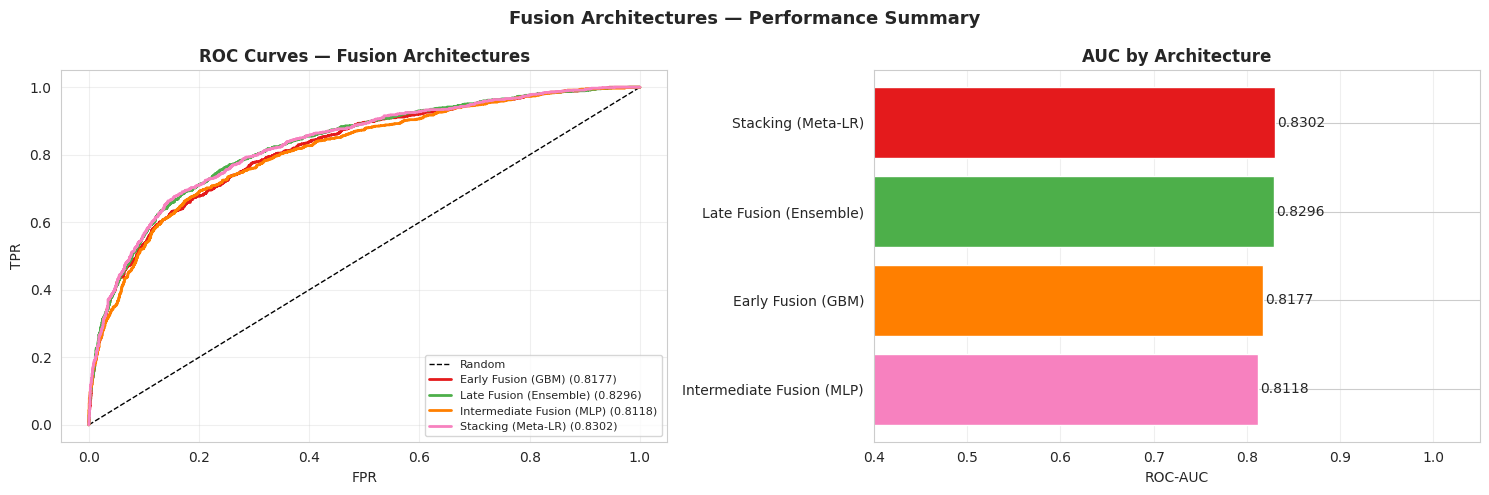


✓ Best architecture: Stacking (Meta-LR) (AUC=0.8302)
Next: 03_ablation_studies.ipynb


In [7]:
# Build comparison table
comp_rows = []
for name, r in fusion_results.items():
    comp_rows.append({
        'Architecture': name,
        'Accuracy': round(r['accuracy'], 4),
        'F1': round(r['f1'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'ROC-AUC': round(r['roc_auc'], 4),
        'Brier': round(r['brier'], 4),
    })

comp_df = pd.DataFrame(comp_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('FUSION ARCHITECTURE COMPARISON')
print('=' * 80)
print(comp_df.to_string(index=False))
comp_df.to_csv(FUSION_DIR / '02_fusion_comparison.csv', index=False)

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
palette = plt.cm.Set1(np.linspace(0, 0.8, len(fusion_results)))
for (name, r), color in zip(fusion_results.items(), palette):
    fpr, tpr, _ = roc_curve(y_val, r['proba'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} ({r["roc_auc"]:.4f})')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — Fusion Architectures', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# AUC bar chart
ax2 = axes[1]
archs = comp_df['Architecture'].tolist()
aucs  = comp_df['ROC-AUC'].tolist()
bars  = ax2.barh(archs, aucs, color=palette[:len(archs)], edgecolor='white')
for bar, val in zip(bars, aucs):
    ax2.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
ax2.set_xlabel('ROC-AUC'); ax2.set_title('AUC by Architecture', fontweight='bold')
ax2.set_xlim(0.4, 1.05); ax2.invert_yaxis()
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle('Fusion Architectures — Performance Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fusion_architectures_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_arch = comp_df.iloc[0]['Architecture']
print(f'\n✓ Best architecture: {best_arch} (AUC={comp_df.iloc[0]["ROC-AUC"]:.4f})')
print('Next: 03_ablation_studies.ipynb')